# Build ROC Curve and Calculate AUC from Scratch

Create an ROC plot and compute the AUC **without using sklearn's `roc_curve` or `auc` functions**.

### Setup Code


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Generate sample data and train model
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
best_model_moons = RandomForestClassifier(n_estimators=100, random_state=42)
best_model_moons.fit(X_train, y_train)

# Get predictions for test set
y_pred_proba = best_model_moons.predict_proba(X_test)[:, 1]  # Probabilities for class 1

### Create Threshold Array
Create an array of thresholds from 0 to 1:


In [ ]:
# Include 0 and 1, use about 100 points
thresholds = np.linspace(0, 1, 101)

### Calculate TPR and FPR for Each Threshold
For each threshold, calculate True Positive Rate and False Positive Rate:


In [ ]:
def calculate_rates(y_true, y_scores, threshold):
    """
    Calculate TPR and FPR for a given threshold

    HINTS:
    - Predictions: y_scores >= threshold
    - True Positives: Both actual=1 AND predicted=1
    - False Positives: actual=0 BUT predicted=1
    - True Negatives: Both actual=0 AND predicted=0
    - False Negatives: actual=1 BUT predicted=0

    - TPR = TP / (TP + FN) = TP / total_actual_positives
    - FPR = FP / (FP + TN) = FP / total_actual_negatives
    """

    y_pred = (y_scores >= threshold).astype(int)

    # Calculate confusion matrix components
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    # Calculate rates
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    return tpr, fpr

# Calculate TPR and FPR for all thresholds
tpr_list = []
fpr_list = []

for threshold in thresholds:
    tpr, fpr = calculate_rates(y_test, y_pred_proba, threshold)
    tpr_list.append(tpr)
    fpr_list.append(fpr)

tpr_array = np.array(tpr_list)
fpr_array = np.array(fpr_list)

### Plot the ROC Curve


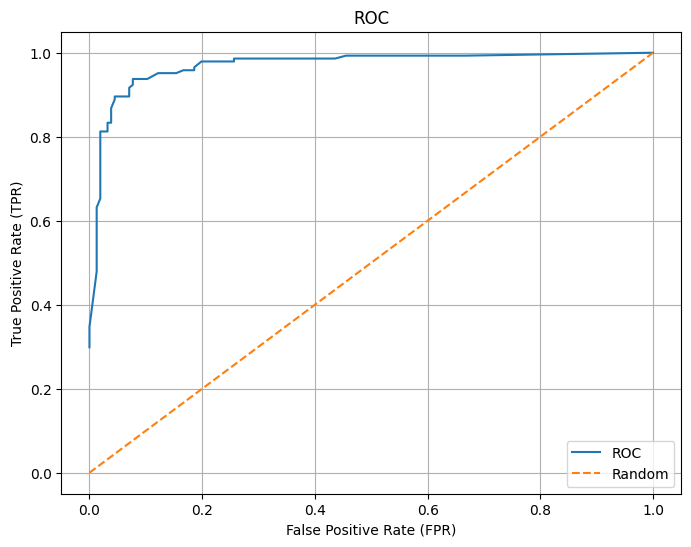

In [ ]:
plt.figure(figsize=(8, 6))
# YOUR CODE: Plot FPR vs TPR
# Add diagonal reference line
# Add labels, title, legend
plt.plot(fpr_array, tpr_array, label='ROC')
plt.plot([0, 1], [0, 1], '--', label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC')
plt.legend()
plt.grid(True)
plt.show()

### Calculate AUC Using Trapezoidal Rule

In [ ]:
def calculate_auc(fpr, tpr):
    """
    Calculate AUC using trapezoidal rule

    HINT: AUC is the area under the ROC curve
    Use np.trapz() or implement manually:
    AUC = sum of (width × average_height) for each trapezoid
    """
    # Sort by FPR to ensure proper order
    sorted_indices = np.argsort(fpr)
    fpr_sorted = fpr[sorted_indices]
    tpr_sorted = tpr[sorted_indices]

    # YOUR CODE: Calculate AUC
    auc = np.trapz(tpr_sorted, fpr_sorted)

    return auc

auc_value = calculate_auc(fpr_array, tpr_array)
print(f"Calculated AUC: {auc_value:.4f}")

Calculated AUC: 0.9698


/tmp/ipython-input-1236599403.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_sorted, fpr_sorted)


### Verify Results
Compare with sklearn's implementation:


In [ ]:
from sklearn.metrics import roc_curve, auc

# sklearn's ROC curve
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_pred_proba)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

print(f"Your AUC: {auc_value:.4f}")
print(f"Sklearn AUC: {auc_sklearn:.4f}")
print(f"Difference: {abs(auc_value - auc_sklearn):.6f}")

Your AUC: 0.9698
Sklearn AUC: 0.9703
Difference: 0.000534


## Notes:

1.  **Why do we sort by FPR before calculating AUC?**
    *   We sort by False Positive Rate (FPR) because it serves as the x-axis for the ROC curve. Sorting ensures that the points are ordered correctly along the x-axis, which is crucial for accurately calculating the area under the curve using methods like the trapezoidal rule.

2.  **What does an AUC of 0.5 mean? What about 1.0?**
    *   **AUC of 0.5**: An AUC of 0.5 indicates that the model's performance is no better than random guessing. This means the model has no discriminative power between positive and negative classes.
    *   **AUC of 1.0**: An AUC of 1.0 signifies a perfect model. It means the model can perfectly distinguish between positive and negative classes for all possible threshold settings, achieving a 100% True Positive Rate and 0% False Positive Rate simultaneously.

3.  **How should I handle the case where all predictions have the same probability?**
    *   If all predictions have the same probability, the model is essentially assigning the same likelihood to all instances. In this scenario, the ROC curve would typically be a single point or a very short vertical/horizontal line, and the AUC would often be 0.5 (random guessing), as the model provides no useful differentiation between classes based on its probability outputs. Special handling might involve:
        *   Recognizing this as a failure of the model to learn meaningful patterns.
        *   Assigning all instances to the majority class, or treating them as random classifications, which would still result in an AUC around 0.5.